In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import seaborn as sns
import matplotlib.colors as clr
from scipy.stats import gaussian_kde
import scipy.sparse as sp
import os


warnings.filterwarnings("ignore")

In [2]:
# Load joint data

adata_folder = '/home/dpatravali/Desktop/IL-15_KO_Pipeline/figure_scripts/Dhruv_Clone13_Figures/adatas'

neighborhood_adata_path = (os.path.join(adata_folder, '06_joint_neighborhoods.h5ad'))

adata = sc.read_h5ad(neighborhood_adata_path)

In [3]:
adata.obs['infection'].value_counts()

infection
Clone13      674090
Armstrong    596928
Name: count, dtype: int64

In [4]:
# Split adata into armstrong and clone13

arm_adata = adata[adata.obs['infection'] == 'Armstrong'].copy()
cl13_adata = adata[adata.obs['infection'] == 'Clone13'].copy()

print(arm_adata.obs['infection'].value_counts())
print(cl13_adata.obs['infection'].value_counts())


infection
Armstrong    596928
Name: count, dtype: int64
infection
Clone13    674090
Name: count, dtype: int64


In [5]:
# ── Diagnostic: check that epithelial_distance & crypt_villi_axis exist and look sane ──

for label, ad in [("Armstrong", arm_adata), ("Clone 13", cl13_adata)]:
    print(f"\n{'='*60}")
    print(f"  {label}  ({ad.n_obs:,} cells)")
    print(f"{'='*60}")

    for col in ["epithelial_distance", "epithelial_distance_clipped", "crypt_villi_axis"]:
        if col in ad.obs.columns:
            vals = pd.to_numeric(ad.obs[col], errors="coerce")
            n_nan = vals.isna().sum()
            print(f"  {col:>35s}  |  min={vals.min():.4f}  max={vals.max():.4f}"
                  f"  median={vals.median():.4f}  NaN={n_nan}")
        else:
            print(f"  {col:>35s}  |  *** MISSING ***")

    print()

# Also load the ORIGINAL individual files and compare
print("\n" + "="*60)
print("  Comparing with original source files")
print("="*60)
try:
    arm_orig = sc.read_h5ad('/mnt/sata1/Dhruv_Analysis_1/spatial_paper_data/spatial_data_all_cells.h5ad')
    print(f"\n  Armstrong original ({arm_orig.n_obs:,} cells):")
    for col in ["epithelial_distance", "epithelial_distance_clipped", "crypt_villi_axis"]:
        if col in arm_orig.obs.columns:
            vals = pd.to_numeric(arm_orig.obs[col], errors="coerce")
            print(f"    {col:>35s}  |  min={vals.min():.4f}  max={vals.max():.4f}  median={vals.median():.4f}")
        else:
            print(f"    {col:>35s}  |  *** MISSING ***")
except Exception as e:
    print(f"  Could not load Armstrong original: {e}")

try:
    cl13_orig = sc.read_h5ad('/mnt/sata1/Dhruv_Analysis_1/2025_10_31_Clone13/combined/final_adata.h5ad')
    print(f"\n  Clone 13 original ({cl13_orig.n_obs:,} cells):")
    for col in ["epithelial_distance", "epithelial_distance_clipped", "crypt_villi_axis"]:
        if col in cl13_orig.obs.columns:
            vals = pd.to_numeric(cl13_orig.obs[col], errors="coerce")
            print(f"    {col:>35s}  |  min={vals.min():.4f}  max={vals.max():.4f}  median={vals.median():.4f}")
        else:
            print(f"    {col:>35s}  |  *** MISSING ***")
except Exception as e:
    print(f"  Could not load Clone 13 original: {e}")



  Armstrong  (596,928 cells)
                  epithelial_distance  |  min=0.1376  max=6.3479  median=0.1557  NaN=0
          epithelial_distance_clipped  |  min=0.1376  max=0.6000  median=0.1557  NaN=0
                     crypt_villi_axis  |  min=0.0193  max=0.9843  median=0.3521  NaN=0


  Clone 13  (674,090 cells)
                  epithelial_distance  |  min=0.0000  max=7.8947  median=0.0314  NaN=0
          epithelial_distance_clipped  |  min=0.0000  max=2.0000  median=0.0314  NaN=0
                     crypt_villi_axis  |  min=0.1461  max=0.9990  median=0.3941  NaN=0


  Comparing with original source files

  Armstrong original (596,928 cells):
                    epithelial_distance  |  min=0.1376  max=6.3479  median=0.1557
            epithelial_distance_clipped  |  min=0.1376  max=0.6000  median=0.1557
                       crypt_villi_axis  |  min=0.0193  max=0.9843  median=0.3521

  Clone 13 original (674,090 cells):
                    epithelial_distance  |  min=0.0000

In [6]:
# Define custom colormap

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

In [7]:
# Define gates

# Clone13 coordinates of the gates for Top LP, Crypt LP, Top IE, and Crypt IE
cl13_gates = {
    "Top IE": {
        "edges": [
            [0.055, 0.555],
            [0.295, 0.555],
            [0.295, 1.03],
            [0.055, 1.03],
        ],
        "label_position": {"x": 0.1, "y": 0.9},
        "fill": "#3A9AB244",
        "stroke": "#3A9AB2",
    },
    "Crypt IE": {
        "edges": [
            [0.055, 0.545],
            [0.295, 0.545],
            [0.295, 0.15],
            [0.055, 0.15],
        ],
        "label_position": {"x": 0.1, "y": 0.3},
        "fill": "#F11B0044",
        "stroke": "#F11B00",
    },
    "Top LP": {
        "edges": [
            [0.305, 0.555],
            [6, 0.555],
            [6, 1.03],
            [0.305, 1.03],
        ],
        "label_position": {"x": 0.5, "y": 0.9},
        "fill": "#F0FEFF44",
        "stroke": "#F0FEFF",
    },
    "Crypt LP": {
        "edges": [
            [0.305, 0.545],
            [6, 0.545],
            [6, 0.295],
            [0.335, 0.15],
            [0.305, 0.15]
        ],
        "label_position": {"x": 0.5, "y": 0.3},
        "fill": "#F7DDDA44",
        "stroke": "#F7DDDA",
    },
    "Muscularis": {
        "edges": [
            [0.34, 0.15], 
            [6, 0.29], 
            [6, .15], 
        ],
        "label_position": {"x": 0.6, "y": 0.2},
        "fill": "#BDC88155",
        "stroke": "#BDC881",
    },
}

# Armstrong coordinates of the gates for Top LP, Crypt LP, Top IE, and Crypt IE
arm_gates = {
    "Top IE": {
        "edges": [
            [0.055, 0.605],
            [0.445, 0.605],
            [0.445, 1.03],
            [0.055, 1.03],
        ],
        "label_position": {"x": 0.1, "y": 0.9},
        "fill": "#3A9AB244",
        "stroke": "#3A9AB2",
    },
    "Crypt IE": {
        "edges": [
            [0.055, 0.595],
            [0.445, 0.595],
            [0.445, 0.23],
            [0.055, 0.23],
        ],
        "label_position": {"x": 0.1, "y": 0.3},
        "fill": "#F11B0044",
        "stroke": "#F11B00",
    },
    "Top LP": {
        "edges": [
            [0.455, 0.605],
            [6, 0.605],
            [6, 1.03],
            [0.455, 1.03],
        ],
        "label_position": {"x": 0.5, "y": 0.9},
        "fill": "#F0FEFF44",
        "stroke": "#F0FEFF",
    },
    "Crypt LP": {
        "edges": [
            [0.455, 0.595],
            [6, 0.595],
            [6, 0.23],
            [0.455, 0.23]
        ],
        "label_position": {"x": 0.5, "y": 0.3},
        "fill": "#F7DDDA44",
        "stroke": "#F7DDDA",
    },
    "Muscularis": {
        "edges": [
            [0.055, 0.22], 
            [6, 0.22], 
            [6, 0.0], 
            [0.055, 0.0]
        ],
        "label_position": {"x": 0.6, "y": 0.2},
        "fill": "#BDC88155",
        "stroke": "#BDC881",
    },
}

In [8]:
# Manually set batches, what are the x and y?
batches = {
    "batch_1": {"x": 6200, "y": 6200},
    "batch_2": {"x": 5800, "y": 5500},
}

In [9]:
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe


# ── Biexponential transformation (same as 02_density_gates) ──────────
def transformation(x, a=0.1, b=0.1, c=0.5, d=2.5, f=4, w=1):
    """Custom biexponential transformation for the epithelial distance axis."""
    x = np.array(x)
    return a * np.exp(b * (x - w)) - c * np.exp(-d * (x - w)) + f


# ── Draw gates ───────────────────────────────────────────────────────
def draw_gates(ax, gates, transformation=transformation, draw_type="both"):
    """
    Draw IMAP gate polygons on a matplotlib Axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    gates : dict
        Gate definitions with 'edges', 'fill', 'stroke', and 'label_position'.
    transformation : callable
        Applied to the x-coordinates of the gate edges.
    draw_type : str
        'fill' (background only), 'edge' (edges + labels), or 'both'.
    """
    for gate_name, gate_info in gates.items():
        # Transform x-coordinates of gate edges
        points = [
            [transformation(pt[0]), pt[1]]
            for pt in gate_info["edges"]
        ]

        if draw_type in ("fill", "both"):
            poly = MplPolygon(
                points, facecolor=gate_info["fill"], edgecolor="none", zorder=0,
            )
            ax.add_patch(poly)

        if draw_type in ("edge", "both"):
            poly = MplPolygon(
                points, facecolor="none", edgecolor=gate_info["stroke"],
                linewidth=1.5, zorder=3,
            )
            ax.add_patch(poly)

            ax.text(
                transformation(gate_info["label_position"]["x"]),
                gate_info["label_position"]["y"],
                gate_name,
                fontsize=7, fontweight="bold",
                color=gate_info["stroke"],
                path_effects=[pe.withStroke(linewidth=2, foreground="white")],
                ha="left", va="center", zorder=4,
            )


# ── Single-panel cluster imap ────────────────────────────────────────
def plot_cluster_imap(
    adata,
    gates,
    title="",
    cluster_key="cluster_cellcharter",
    transformation=transformation,
    cluster_colors=None,
    ax=None,
    point_size=1,
    alpha=0.7,
    frac=0.1,
    ax_ticks=[0.15, 0.3, 0.6, 1, 6],
    figsize=(8, 6),
    dpi=150,
    shuffle=True,
    seed=42,
    batches=None,  # New parameter: list of batch values to plot. Default None = all in one panel
):
    """
    Plot cells on an IMAP (epithelial distance × crypt–villus axis)
    colored by cluster, with gate region overlays. Can plot a panel (subplot) per batch
    if provided a list of batch values in `batches`.

    Parameters
    ----------
    adata : AnnData
        Must contain 'epithelial_distance' and 'crypt_villi_axis' in obs.
    gates : dict
        Gate definitions (edges in raw epithelial_distance / crypt_villi_axis coords).
    title : str
        Panel title or main title for all subplots.
    cluster_key : str
        Column in adata.obs with cluster labels.
    transformation : callable
        Biexponential transform applied to x (epithelial distance).
    cluster_colors : dict or None
        {cluster_label_str: RGBA tuple}. Auto-generated if None.
    ax : matplotlib.axes.Axes or None, or array of Axes
        If None, a new figure/subplots are created.
    point_size : float
        Scatter marker size.
    alpha : float
        Scatter marker transparency.
    frac : float
        Fraction of cells to randomly sample (0–1). Default 0.1 = 10%.
    ax_ticks : list
        Epithelial distance tick values (raw scale, will be transformed).
    shuffle : bool
        Randomly shuffle plot order so no single cluster always occludes others.
    seed : int
        RNG seed for shuffle reproducibility.
    batches : list or None
        List of batch values to facet by. If None, all batches combined.

    Returns
    -------
    fig, axes : matplotlib Figure and array of Axes if batches supplied; else single Axes
    """

    import math

    # Determine the batch categories to plot
    batch_values = None
    if batches is not None:
        batch_values = batches
    elif "batch" in adata.obs:
        batch_values = [adata.obs["batch"].unique()[0]]  # default: only the first if not given

    # If more than one batch, facet; otherwise, keep legacy behavior
    if batch_values is not None and len(batch_values) > 1:
        n_batches = len(batch_values)
        ncols = min(n_batches, 3)
        nrows = math.ceil(n_batches / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0]*ncols, figsize[1]*nrows), dpi=dpi, squeeze=False)
        axes = axes.flatten()

        # To harmonize cluster colors across batches
        all_clusters = set()
        for batch in batch_values:
            mask = (adata.obs["batch"] == batch)
            clusters = adata.obs.loc[mask, cluster_key].astype(str).unique()
            all_clusters.update(clusters)
        unique_clusters = sorted(all_clusters, key=lambda c: int(c) if c.isdigit() else c)

        if cluster_colors is None:
            n = len(unique_clusters)
            cmap = plt.cm.get_cmap("tab20" if n > 10 else "tab10", max(n, 10))
            cluster_colors = {cl: cmap(i) for i, cl in enumerate(unique_clusters)}

        for ax_i, batch in enumerate(batch_values):
            batch_mask = (adata.obs["batch"] == batch)
            sub_adata = adata[batch_mask]
            x = transformation(np.array(sub_adata.obs["epithelial_distance"]))
            y = np.array(sub_adata.obs["crypt_villi_axis"])
            clusters = sub_adata.obs[cluster_key].astype(str).values

            rng = np.random.default_rng(seed)
            n_total = len(x)
            n_sample = max(1, int(n_total * frac))
            if n_total == 0:
                continue  # skip empty batch
            idx = rng.choice(n_total, size=n_sample, replace=False)
            if shuffle:
                rng.shuffle(idx)

            cell_colors = np.array([cluster_colors[c] for c in clusters[idx]])

            axes[ax_i].scatter(
                x[idx], y[idx],
                c=cell_colors,
                s=point_size,
                alpha=alpha,
                edgecolors="none",
                rasterized=True,
                zorder=1,
            )
            draw_gates(axes[ax_i], gates, transformation=transformation, draw_type="edge")
            axes[ax_i].set_xticks(transformation(ax_ticks))
            axes[ax_i].set_xticklabels(ax_ticks)
            axes[ax_i].set_ylim(-0.02, 1.05)
            axes[ax_i].set_xlabel("Epithelial Distance")
            axes[ax_i].set_ylabel("Crypt–Villus Axis")
            axes[ax_i].set_title(f"{title} (batch: {batch})", fontsize=12, fontweight="bold")

        # Shared legend (on last axis)
        handles = [
            Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=cluster_colors[cl], markersize=8,
                   label=f"Cluster {cl}")
            for cl in unique_clusters
        ]
        axes[-1].legend(
            handles=handles, title="Cluster",
            fontsize=8, title_fontsize=9, frameon=True,
            loc="upper right", markerscale=1,
        )

        # Remove unused axes if any
        for extra_ax in axes[n_batches:]:
            extra_ax.set_visible(False)

        plt.tight_layout()
        return fig, axes[:n_batches]

    else:
        # Legacy: single panel for all batches or just one
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

        x = transformation(np.array(adata.obs["epithelial_distance"]))
        y = np.array(adata.obs["crypt_villi_axis"])
        clusters = adata.obs[cluster_key].astype(str).values
        unique_clusters = sorted(
            set(clusters),
            key=lambda c: int(c) if c.isdigit() else c,
        )

        if cluster_colors is None:
            n = len(unique_clusters)
            cmap = plt.cm.get_cmap("tab20" if n > 10 else "tab10", max(n, 10))
            cluster_colors = {cl: cmap(i) for i, cl in enumerate(unique_clusters)}

        rng = np.random.default_rng(seed)
        n_total = len(x)
        n_sample = max(1, int(n_total * frac))
        idx = rng.choice(n_total, size=n_sample, replace=False)
        if shuffle:
            rng.shuffle(idx)

        cell_colors = np.array([cluster_colors[c] for c in clusters[idx]])

        ax.scatter(
            x[idx], y[idx],
            c=cell_colors,
            s=point_size,
            alpha=alpha,
            edgecolors="none",
            rasterized=True,
            zorder=1,
        )

        draw_gates(ax, gates, transformation=transformation, draw_type="edge")

        ax.set_xticks(transformation(ax_ticks))
        ax.set_xticklabels(ax_ticks)
        ax.set_ylim(-0.02, 1.05)
        ax.set_xlabel("Epithelial Distance")
        ax.set_ylabel("Crypt–Villus Axis")
        ax.set_title(title, fontsize=12, fontweight="bold")

        handles = [
            Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=cluster_colors[cl], markersize=8,
                   label=f"Cluster {cl}")
            for cl in unique_clusters
        ]
        ax.legend(
            handles=handles, title="Cluster",
            fontsize=8, title_fontsize=9, frameon=True,
            loc="upper right", markerscale=1,
        )

        plt.tight_layout()
        return ax


# ── Build a shared colour palette ────────────────────────────────────
def build_shared_cluster_colors(*adatas, cluster_key="cluster_cellcharter"):
    """
    Build a colour dict that is consistent across multiple AnnData objects
    so the same cluster always gets the same colour.
    """
    all_clusters = sorted(
        set().union(*(set(ad.obs[cluster_key].astype(str).unique()) for ad in adatas)),
        key=lambda c: int(c) if c.isdigit() else c,
    )
    n = len(all_clusters)
    cmap = plt.cm.get_cmap("tab20" if n > 10 else "tab10", max(n, 10))
    return {cl: cmap(i) for i, cl in enumerate(all_clusters)}



In [10]:
# ── Grouped bar chart comparing cluster proportions across conditions ──────
def plot_cluster_bar(
    adatas,
    cluster_key="cluster_cellcharter",
    title="Proportion of Cells per Cluster",
    colors=None,
    figsize=(10, 5),
    dpi=150,
):
    """
    Grouped bar chart showing the **proportion** of cells in each cluster
    for multiple AnnData objects, so conditions with different total cell
    counts are directly comparable.

    Parameters
    ----------
    adatas : dict
        {label: AnnData} – each entry becomes one bar group.
        Example: {"Armstrong": arm_adata, "Clone 13": cl13_adata}
    cluster_key : str
        Column in adata.obs containing cluster labels.
    title : str
        Plot title.
    colors : list of str or None
        One colour per condition. Defaults to a sensible palette.
    figsize : tuple
    dpi : int
    """
    labels = list(adatas.keys())
    n_cond = len(labels)

    # Count cells per cluster for every condition
    counts = {
        lab: ad.obs[cluster_key].astype(str).value_counts()
        for lab, ad in adatas.items()
    }

    # Normalise counts → proportions within each condition
    proportions = {
        lab: cts / cts.sum()
        for lab, cts in counts.items()
    }

    # Union of all cluster labels, sorted numerically
    all_clusters = sorted(
        set().union(*(set(c.index) for c in counts.values())),
        key=lambda c: int(c) if c.isdigit() else c,
    )

    # Default colours
    if colors is None:
        default_pal = ["#3A9AB2", "#F11B00", "#BDC881", "#E79805",
                       "#6FB2C1", "#EF5703", "#91BAB6", "#DCCB4E"]
        colors = default_pal[:n_cond]

    # Bar positions
    x = np.arange(len(all_clusters))
    total_width = 0.8
    bar_width = total_width / n_cond

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    for i, lab in enumerate(labels):
        vals = [proportions[lab].get(c, 0) for c in all_clusters]
        offset = -total_width / 2 + bar_width * (i + 0.5)
        ax.bar(x + offset, vals, width=bar_width, label=lab,
               color=colors[i], edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([f"Cluster {c}" for c in all_clusters],
                       rotation=45, ha="right")
    ax.set_ylabel("Proportion of Cells")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(frameon=True)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

### Plot for All Cells

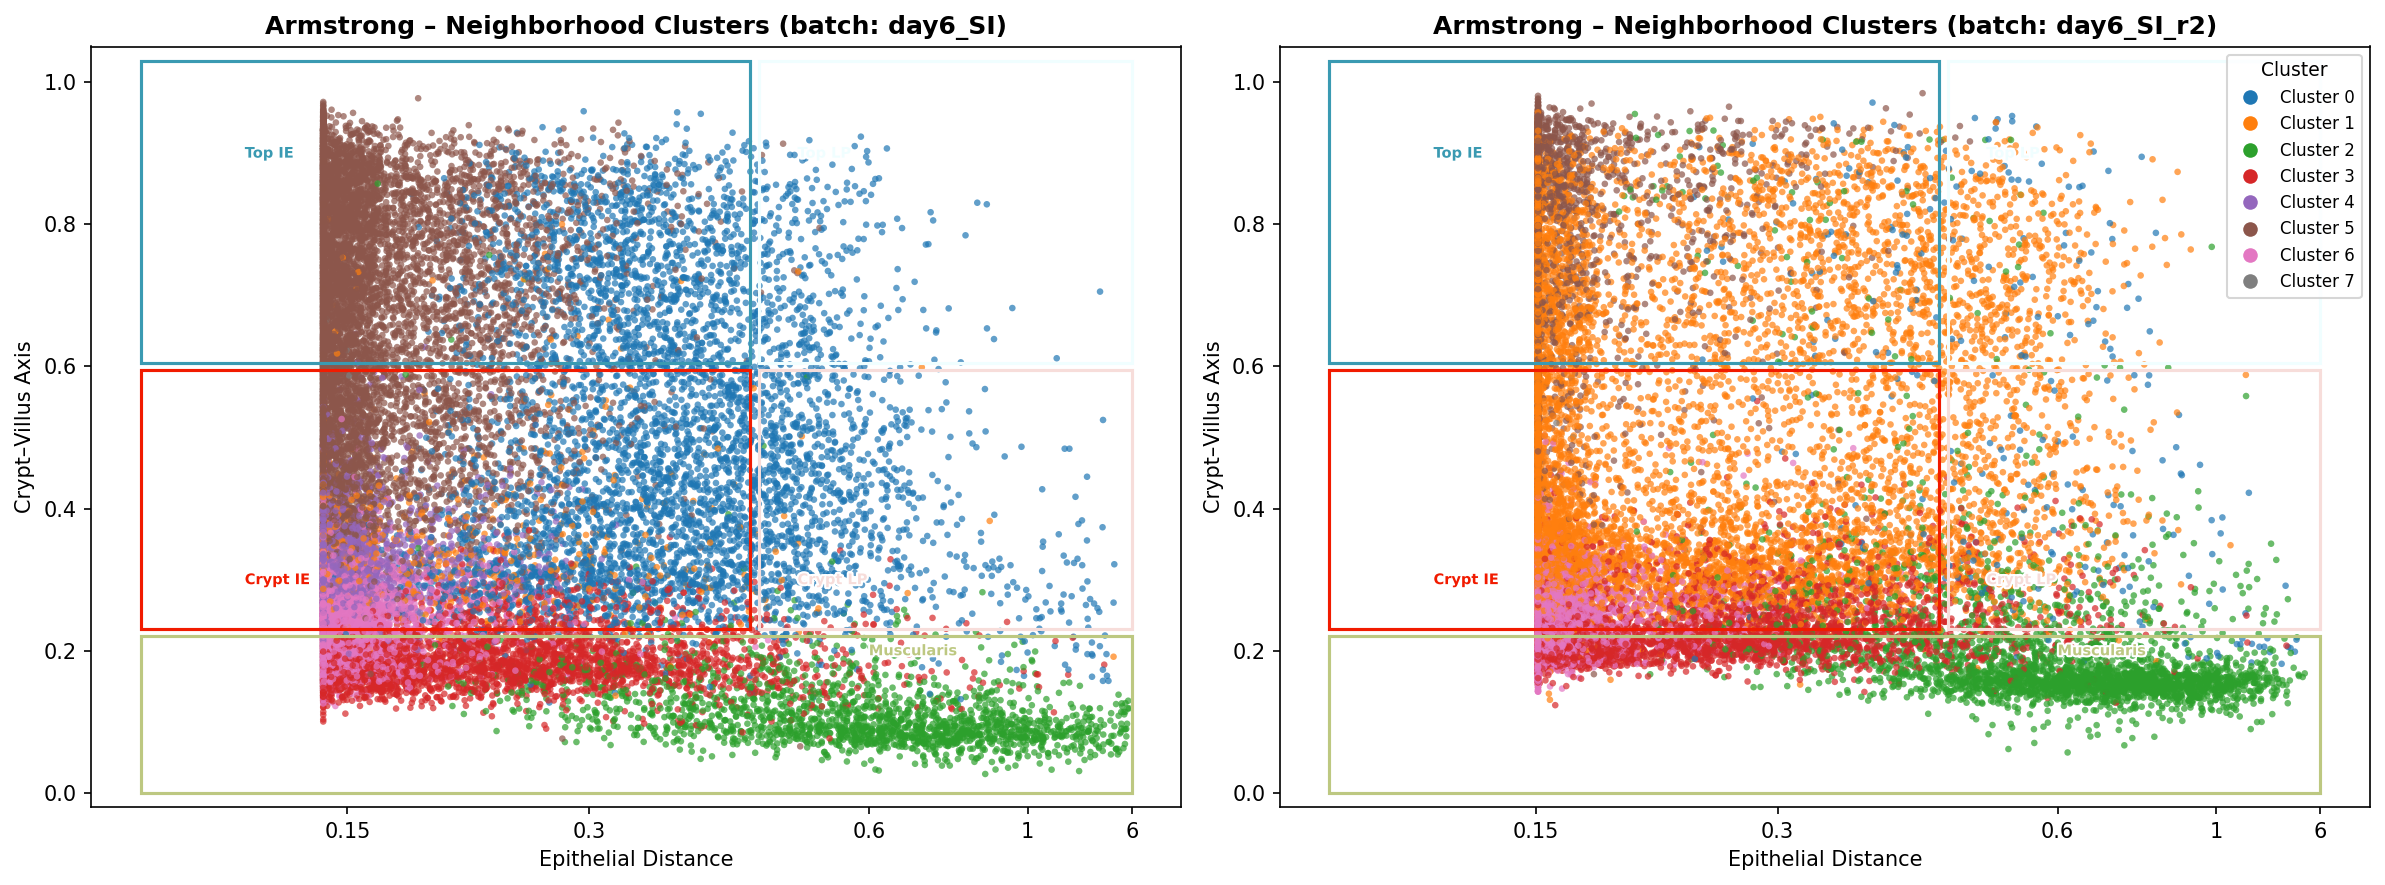

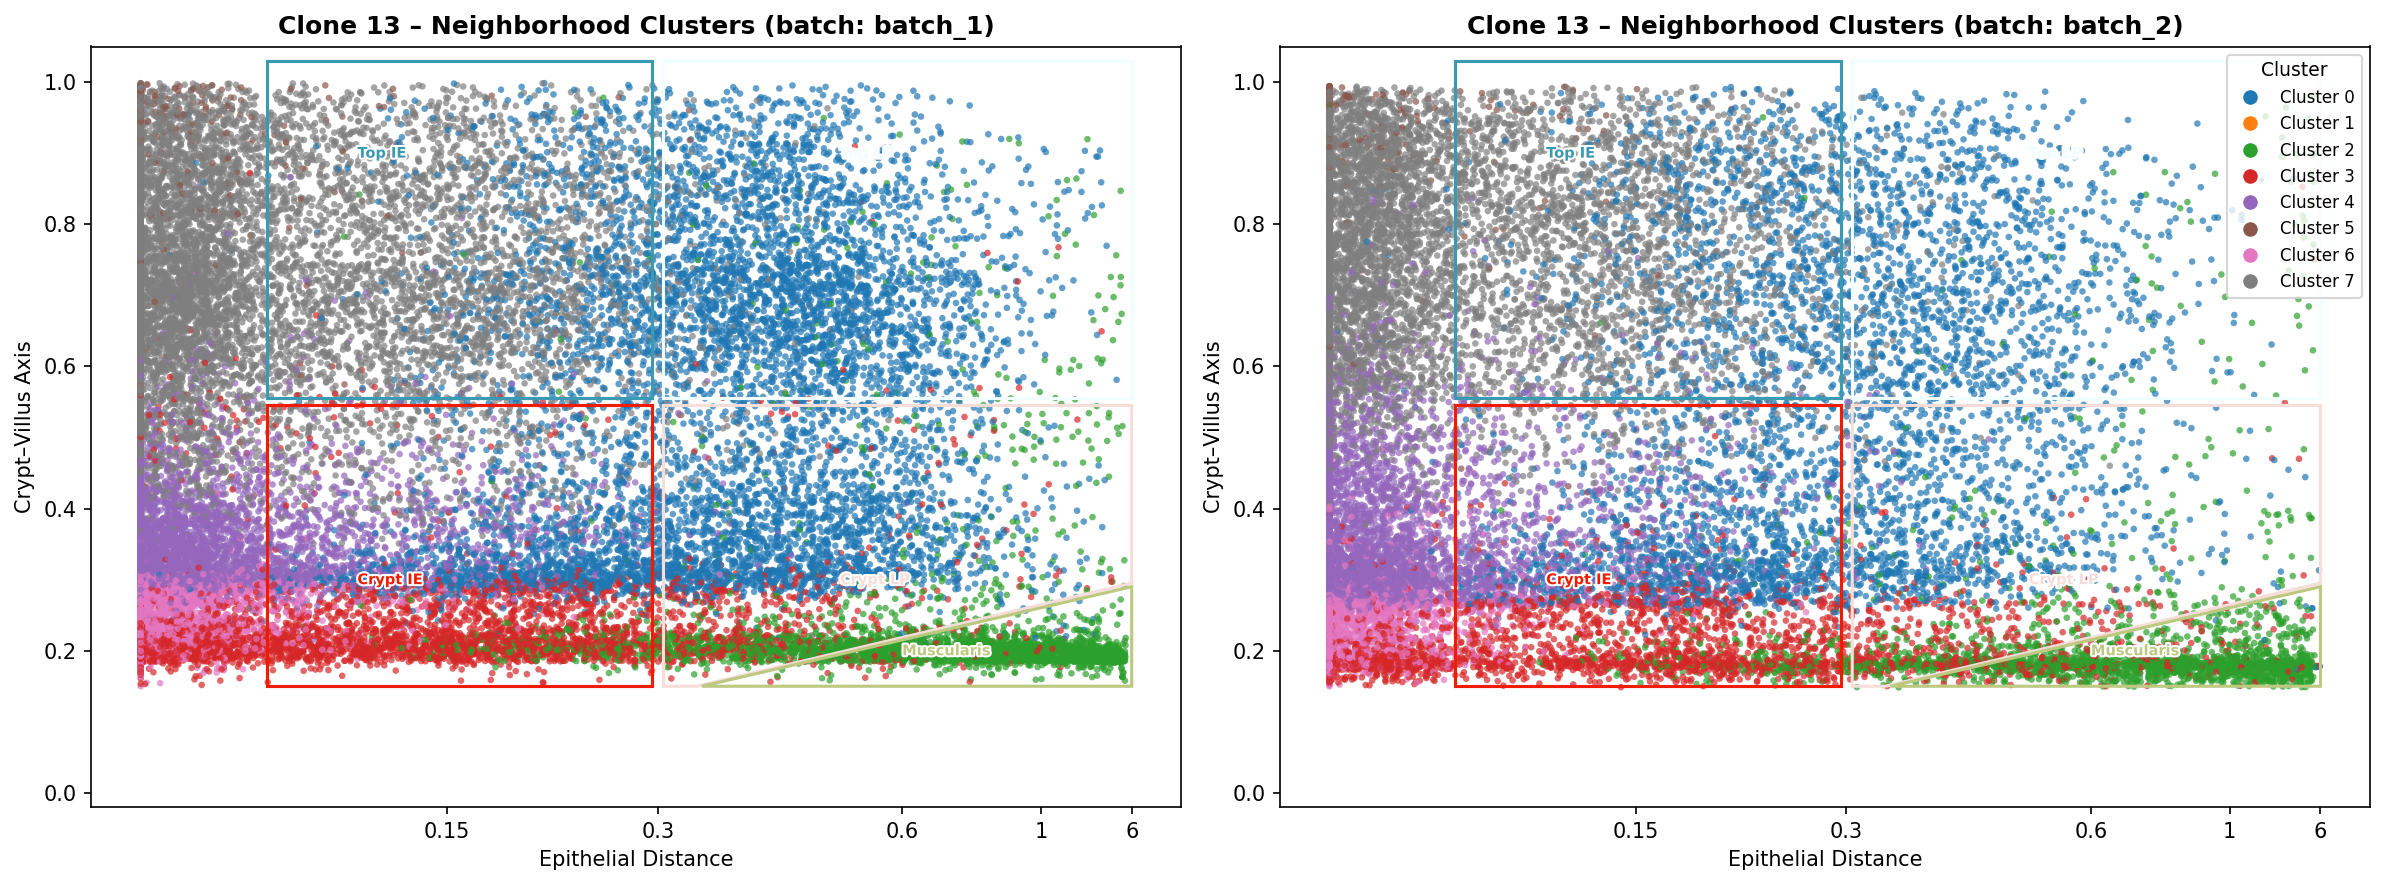

In [11]:
# Shared colour palette so both plots use the same cluster → colour mapping
cluster_colors = build_shared_cluster_colors(arm_adata, cl13_adata)

# ── Armstrong ──
plot_cluster_imap(
    arm_adata, arm_gates,
    title="Armstrong – Neighborhood Clusters",
    cluster_colors=cluster_colors,
    frac=0.1,
    point_size=10,
    alpha=0.7,
    dpi=150,
    figsize=(8, 6),
    batches=['day6_SI', 'day6_SI_r2']
)
plt.show()

# ── Clone 13 ──
plot_cluster_imap(
    cl13_adata, cl13_gates,
    title="Clone 13 – Neighborhood Clusters",
    cluster_colors=cluster_colors,
    frac=0.1,
    point_size=10,
    alpha=0.7,
    dpi=150,
    figsize=(8, 6),
    batches=['batch_1', 'batch_2']
)
plt.show()


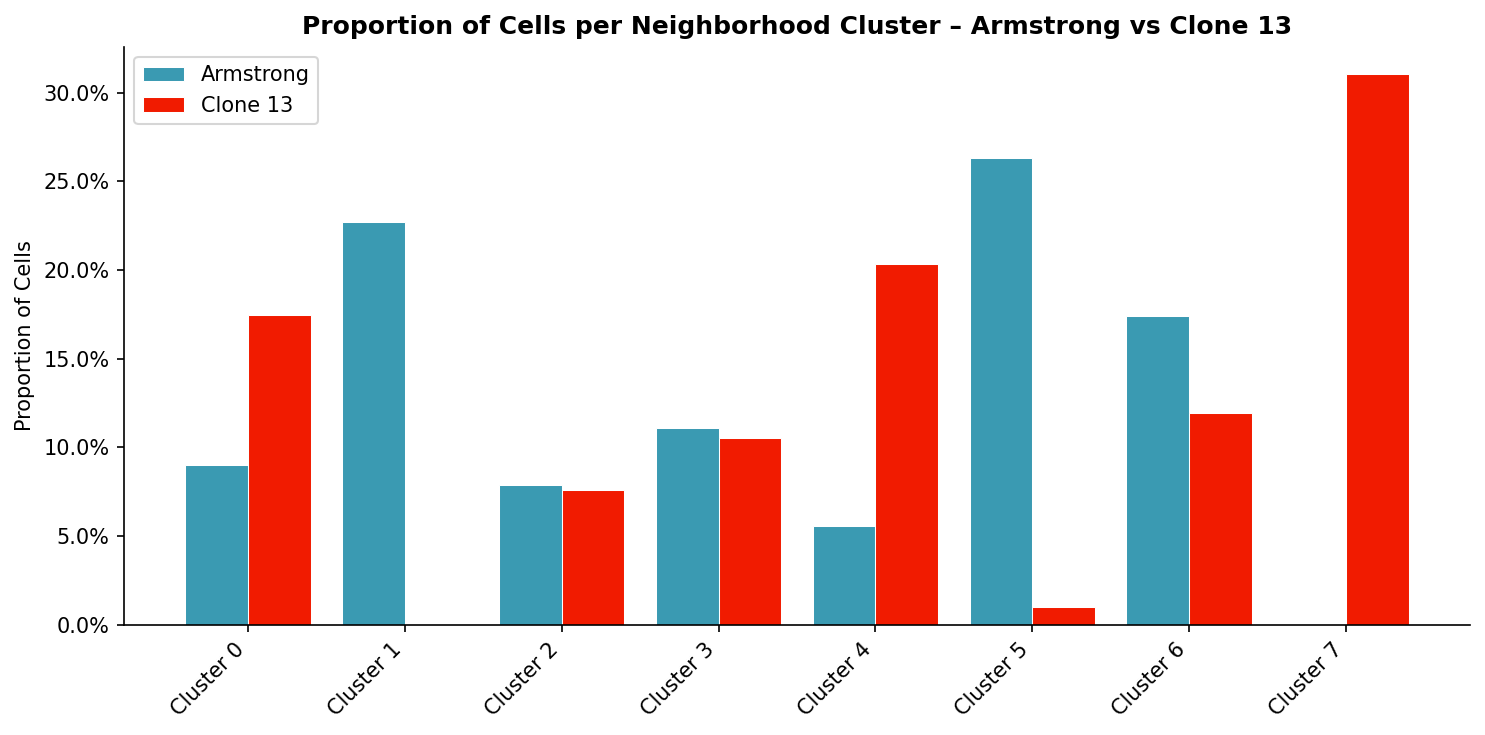

In [12]:
plot_cluster_bar(
    {"Armstrong": arm_adata, "Clone 13": cl13_adata},
    cluster_key="cluster_cellcharter",
    title="Proportion of Cells per Neighborhood Cluster – Armstrong vs Clone 13",
)


### Plot for P14 Cells

In [13]:
# Load in adata

# Filter cells for Xist expression and P14 & ab+ Cd8 T cells
gidx = arm_adata.var_names.get_loc('Xist')
X = arm_adata.X
if sp.issparse(X):
    mask = X[:, gidx].toarray().ravel() > 0
else:
    mask = X[:, gidx] > 0

arm_adata_xist = arm_adata[mask].copy()
print(arm_adata.obs.shape)
print(arm_adata_xist.obs.shape)

arm_p14_adata = arm_adata_xist[arm_adata_xist.obs['Subtype'].isin(['Cd8_T-Cell_P14', 'Cd8_T-Cell_ab+'])]

(596928, 48)
(21443, 48)


In [14]:
# Load in adata

# Filter cells for Xist expression and P14 & ab+ Cd8 T cells
gidx = cl13_adata.var_names.get_loc('Xist')
X = cl13_adata.X
if sp.issparse(X):
    mask = X[:, gidx].toarray().ravel() > 0
else:
    mask = X[:, gidx] > 0

cl13_adata_xist = cl13_adata[mask].copy()
print(cl13_adata.obs.shape)
print(cl13_adata_xist.obs.shape)

cl13_p14_adata = cl13_adata_xist[cl13_adata_xist.obs['Subtype'].isin(['Cd8_T-Cell_P14', 'Cd8_T-Cell_ab+'])]

(674090, 48)
(7422, 48)


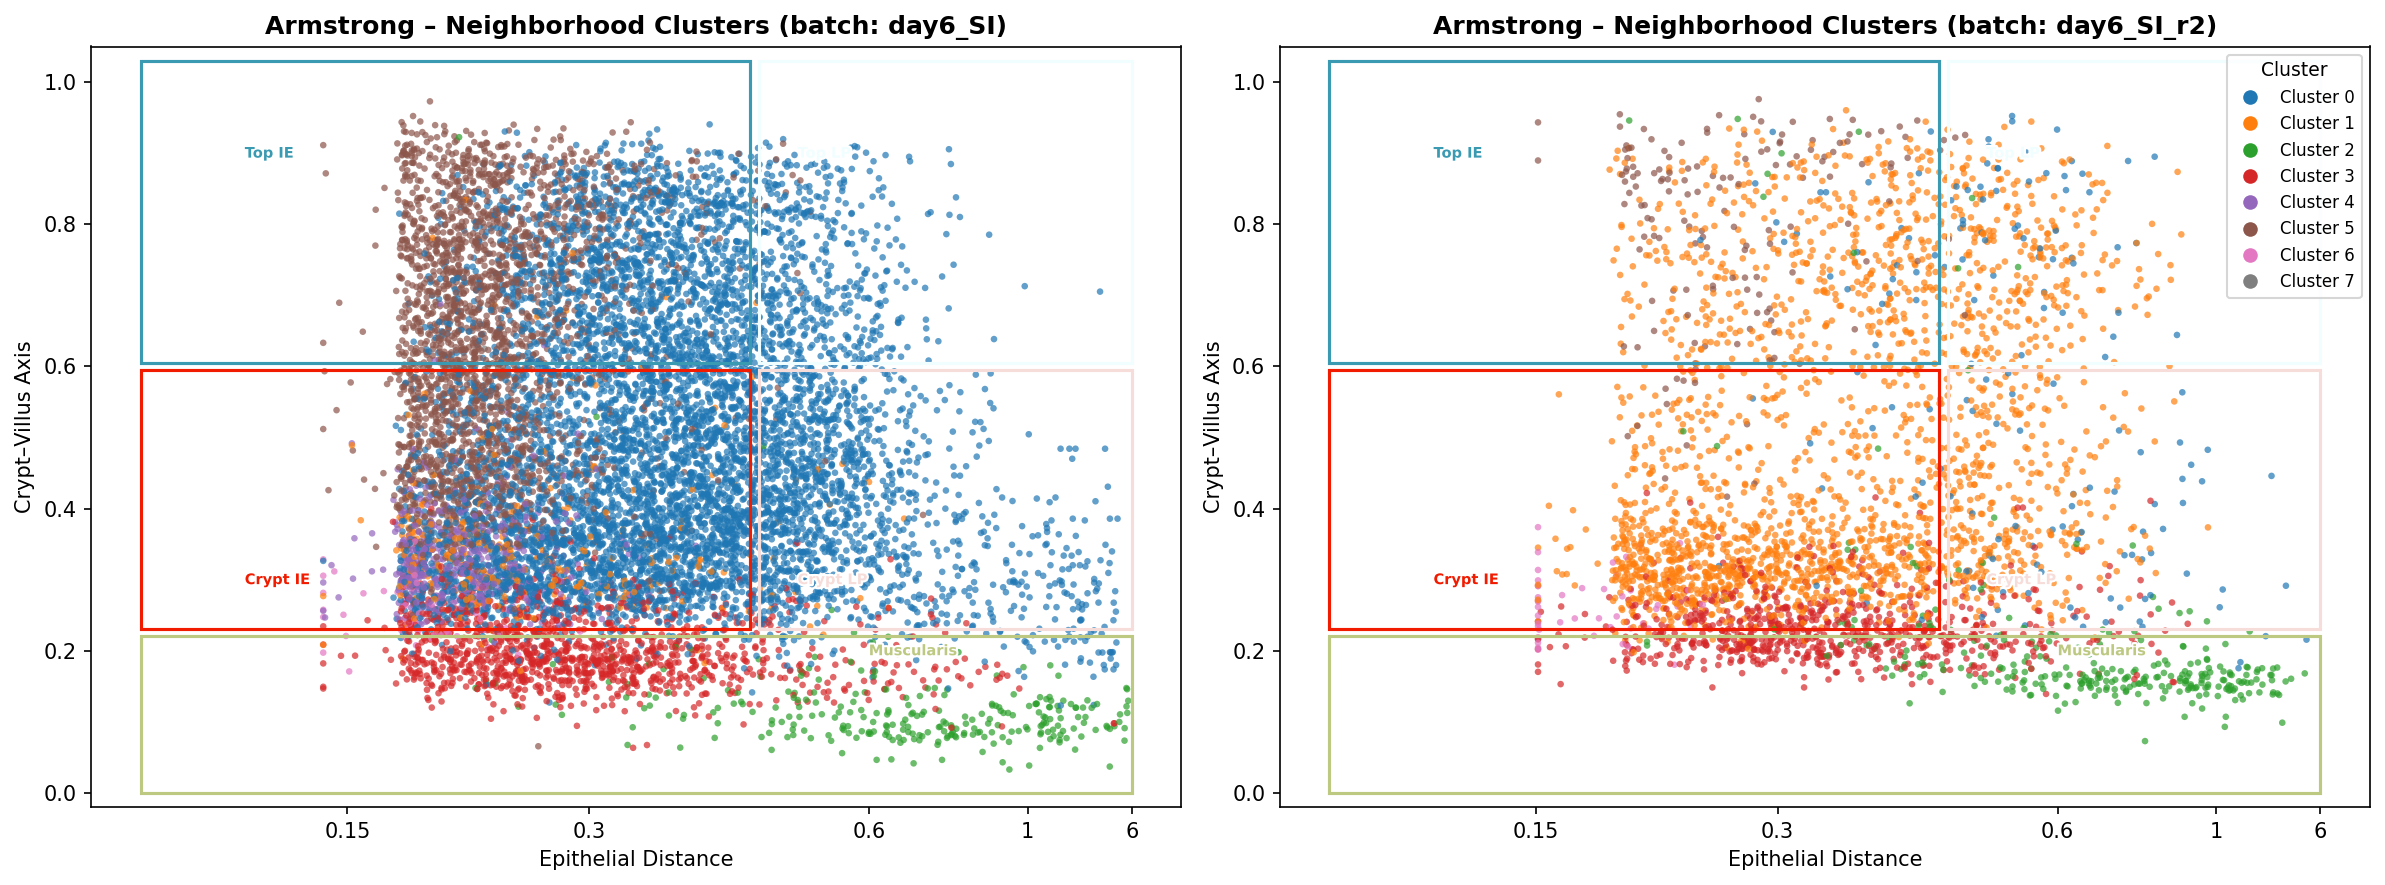

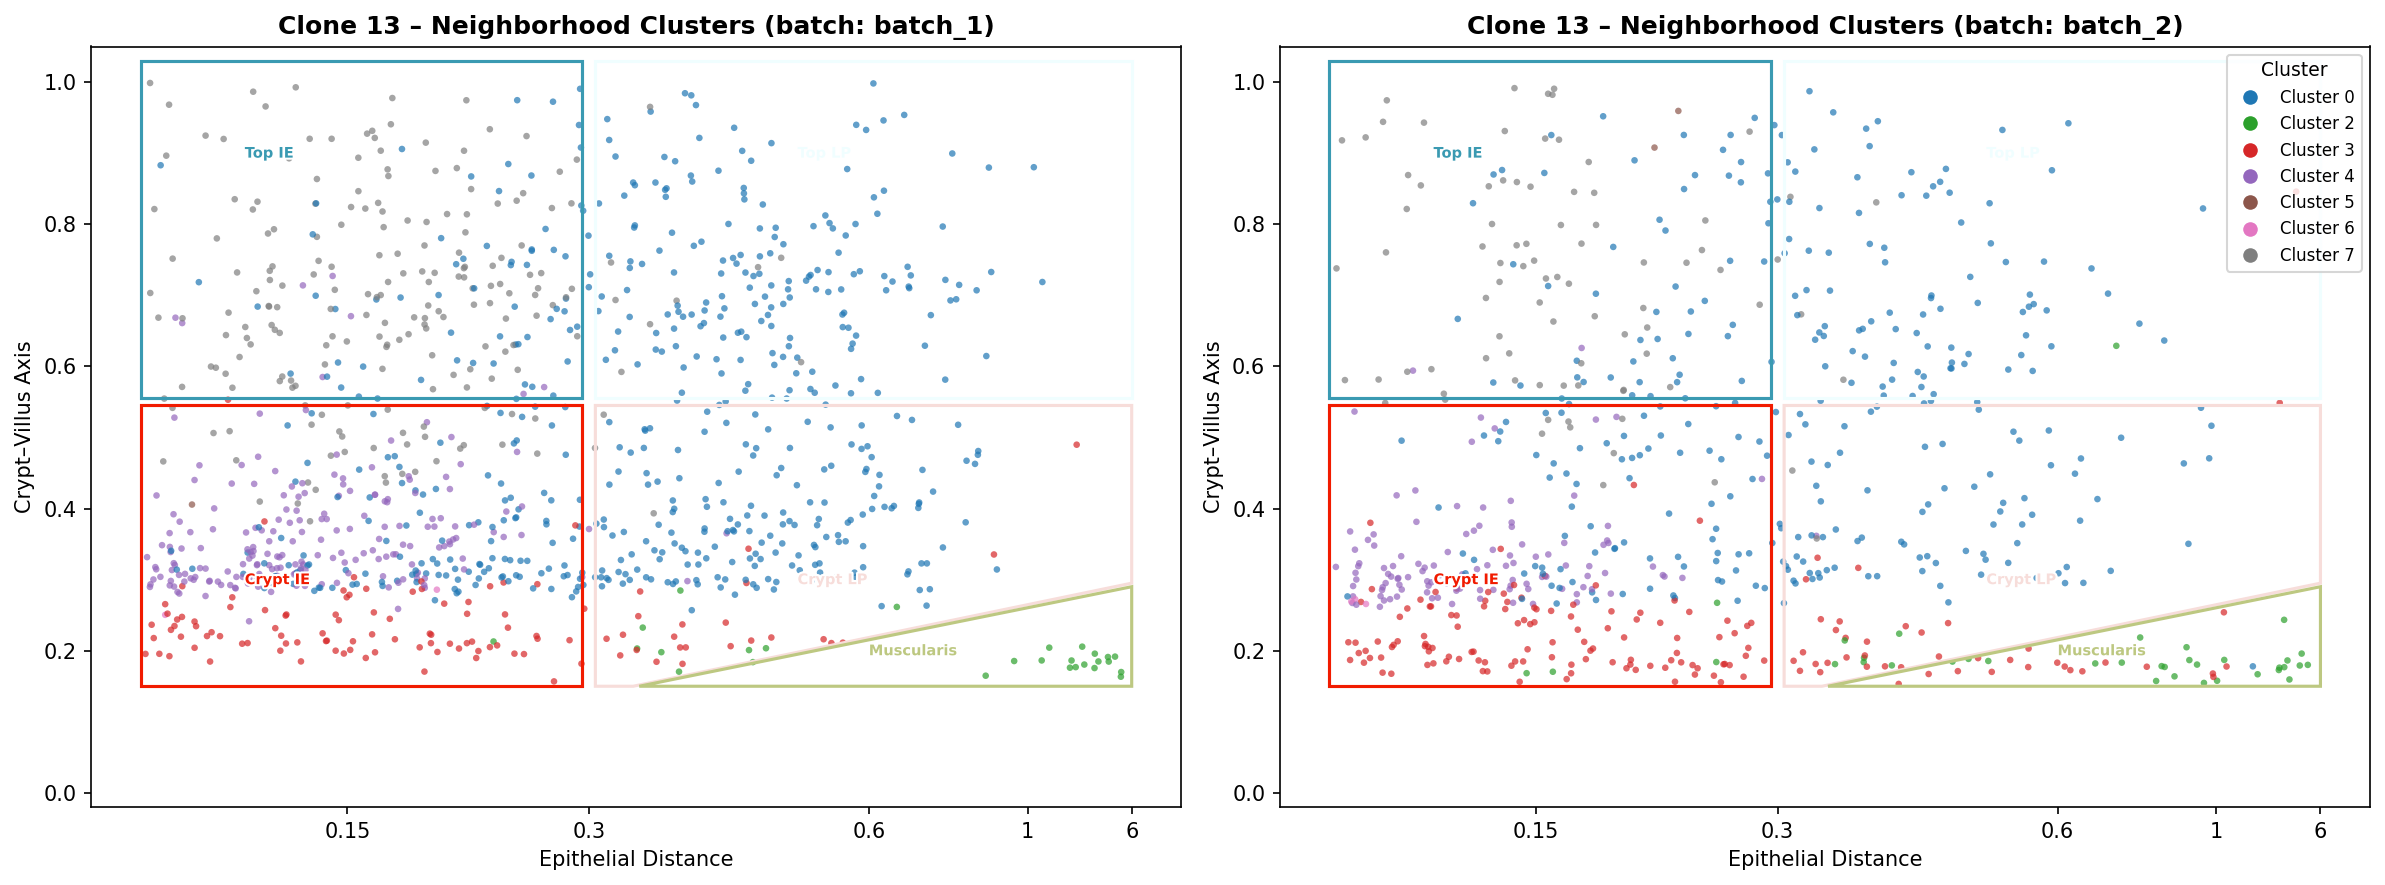

In [15]:
# Shared colour palette so both plots use the same cluster → colour mapping
cluster_colors = build_shared_cluster_colors(arm_adata, cl13_adata)

# ── Armstrong ──
plot_cluster_imap(
    arm_p14_adata, arm_gates,
    title="Armstrong – Neighborhood Clusters",
    cluster_colors=cluster_colors,
    frac=1.0,
    point_size=10,
    alpha=0.7,
    dpi=150,
    figsize=(8, 6),
    batches=['day6_SI', 'day6_SI_r2']
)
plt.show()

# ── Clone 13 ──
plot_cluster_imap(
    cl13_p14_adata, cl13_gates,
    title="Clone 13 – Neighborhood Clusters",
    cluster_colors=cluster_colors,
    frac=1.0,
    point_size=10,
    alpha=0.7,
    dpi=150,
    figsize=(8, 6),
    batches=['batch_1', 'batch_2']
)
plt.show()


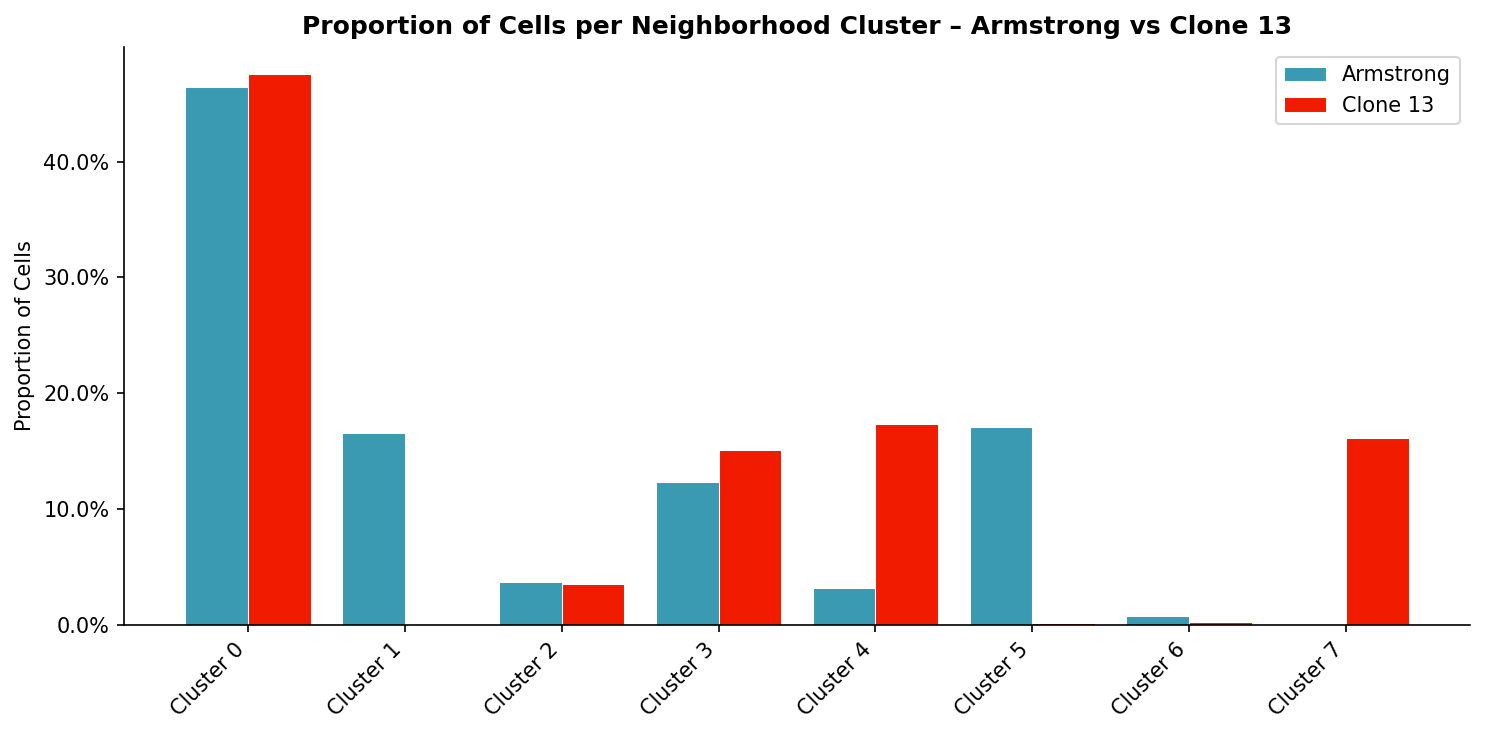

In [16]:
plot_cluster_bar(
    {"Armstrong": arm_p14_adata, "Clone 13": cl13_p14_adata},
    cluster_key="cluster_cellcharter",
    title="Proportion of Cells per Neighborhood Cluster – Armstrong vs Clone 13",
)
